# Modeling: seasonal z-score, MAD, and Isolation Forest

Team 16 - Gunn Madan, Harini Mohan

Fits all three detectors on the 2016-2022 training window and scores 2023-2026 so none of the baseline statistics leak from the future. Output is written to `data/model_output_data.csv` and used in notebook 03 for evaluation.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import pandas as pd
import matplotlib.pyplot as plt

import feature_engineering as fe
import models as md

DATA_DIR = os.path.abspath(os.path.join('..', 'data'))

feat = pd.read_csv(os.path.join(DATA_DIR, 'clean_weather_data.csv'))
feat['DATE'] = pd.to_datetime(feat['DATE'])
feat.head()

,DATE,CITY,TMAX,TMIN,PRCP,month,dayofyear,temp_range,rolling_mean,rolling_std,rolling_mean_tmin,rolling_mean_prcp
0,2016-01-07,Chicago,41.0,34.0,0.01,1,7,7.0,33.285714,4.029652,22.142857,0.001429
1,2016-01-08,Chicago,42.0,36.0,0.19,1,8,6.0,34.857143,5.014265,24.571429,0.028571
2,2016-01-09,Chicago,40.0,23.0,0.27,1,9,17.0,36.000000,5.163978,25.000000,0.067143
3,2016-01-10,Chicago,23.0,2.0,0.00,1,10,21.0,35.142857,6.768273,22.142857,0.067143
4,2016-01-11,Chicago,24.0,-1.0,0.11,1,11,25.0,34.142857,7.904188,18.857143,0.082857


## Time-based train/test split

Train window is strictly before the split date so seasonal baselines (mean/std/median/MAD) contain no test-period information. The Isolation Forest is trained on the same window.

In [2]:
train, test = fe.time_split(feat, split_date='2023-01-01')
print('Train rows:', len(train), 'date range:', train['DATE'].min().date(), 'to', train['DATE'].max().date())
print('Test  rows:', len(test),  'date range:', test['DATE'].min().date(),  'to', test['DATE'].max().date())

Train rows: 7653 date range: 2016-01-07 to 2022-12-31
Test  rows: 3517 date range: 2023-01-01 to 2026-03-18


## Seasonal z-score baseline (per city, per day-of-year)

`z = (x - mean) / std` with mean/std computed inside each `(CITY, dayofyear)` group on the training window. Flag when `|z| > 2`.

In [3]:
scored = test.copy()
for var in ['TMAX', 'TMIN', 'PRCP']:
    base = md.fit_seasonal_baseline(train, var)
    scored = md.apply_zscore(scored, base, var)

scored[['DATE', 'CITY', 'TMAX', 'z_TMAX', 'anomaly_z_TMAX']].head()

,DATE,CITY,TMAX,z_TMAX,anomaly_z_TMAX
0,2023-01-01,Chicago,45.0,0.870388,False
1,2023-01-02,Chicago,43.0,0.846183,False
2,2023-01-03,Chicago,48.0,1.647676,False
3,2023-01-04,Chicago,44.0,1.145252,False
4,2023-01-05,Chicago,34.0,0.153314,False


## MAD detector (median absolute deviation)

Robust alternative for heavy-tailed distributions (precipitation especially). Score is a normal-consistent `0.6745 * (x - median) / MAD`; flag when absolute score exceeds 3.5.

In [4]:
for var in ['TMAX', 'TMIN', 'PRCP']:
    mad_base = md.fit_mad_baseline(train, var)
    scored = md.apply_mad(scored, mad_base, var)

scored[['DATE', 'CITY', 'PRCP', 'mad_score_PRCP', 'anomaly_mad_PRCP']].head()

,DATE,CITY,PRCP,mad_score_PRCP,anomaly_mad_PRCP
0,2023-01-01,Chicago,0.16,20.9095,True
1,2023-01-02,Chicago,0.00,-0.6745,False
2,2023-01-03,Chicago,1.12,NaN,False
3,2023-01-04,Chicago,0.00,NaN,False
4,2023-01-05,Chicago,0.02,NaN,False


## Isolation Forest

Unsupervised tree ensemble. Trained on `[TMAX, TMIN, PRCP, temp_range, rolling_mean]` with `contamination=0.02`.

In [5]:
if_features = ['TMAX', 'TMIN', 'PRCP', 'temp_range', 'rolling_mean']
if_model = md.fit_isolation_forest(train, if_features)
scored = md.apply_isolation_forest(scored, if_model, if_features)

scored[['DATE', 'CITY', 'TMAX', 'if_score', 'anomaly_if']].head()

,DATE,CITY,TMAX,if_score,anomaly_if
0,2023-01-01,Chicago,45.0,0.472615,False
1,2023-01-02,Chicago,43.0,0.419274,False
2,2023-01-03,Chicago,48.0,0.568544,False
3,2023-01-04,Chicago,44.0,0.422240,False
4,2023-01-05,Chicago,34.0,0.499520,False


In [6]:
scored.to_csv(os.path.join(DATA_DIR, 'model_output_data.csv'), index=False)
print('Wrote model_output_data.csv with', len(scored), 'rows')

Wrote model_output_data.csv with 3517 rows


## Quick visual - NYC TMAX with z-score flags

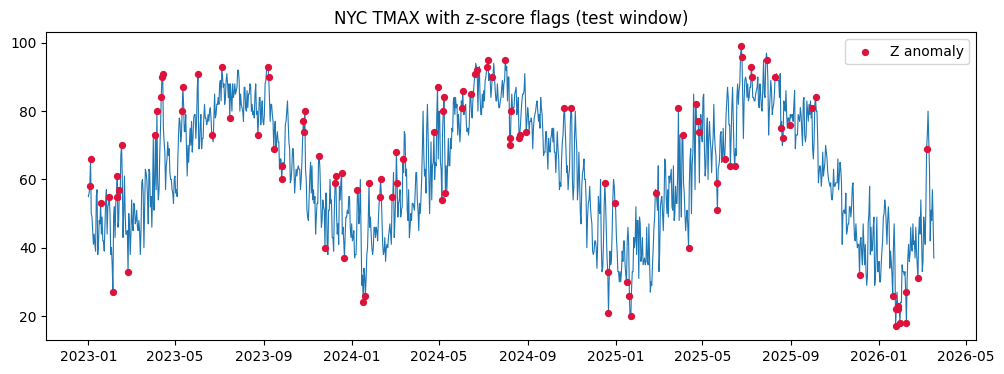

In [7]:
nyc = scored[scored['CITY'] == 'NYC']
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(nyc['DATE'], nyc['TMAX'], linewidth=0.8)
anom = nyc[nyc['anomaly_z_TMAX'].fillna(False)]
ax.scatter(anom['DATE'], anom['TMAX'], color='crimson', s=18, zorder=3, label='Z anomaly')
ax.set_title('NYC TMAX with z-score flags (test window)')
ax.legend()
plt.show()